# OmniLSS Quick Start

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dongfangzhizhu/OmniLSS/blob/main/examples/colab/01_quick_start.ipynb)

Get started with OmniLSS in under 10 minutes.

## Contents
1. Environment setup
2. Install OmniLSS
3. Fit your first model
4. Model diagnostics
5. Compare with R gamlss
6. Performance benchmark


## 1. Environment Setup

In [1]:
import sys
print(f"Python {sys.version}")

try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")


Python 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Running locally


## 2. Install OmniLSS

In [2]:
if IN_COLAB:
    !pip install -q git+https://github.com/dongfangzhizhu/OmniLSS.git#subdirectory=omnilss
else:
    !pip install -q -e ../../omnilss
print("OmniLSS installed")


OmniLSS installed


In [3]:
import jax
import jax.numpy as jnp
print(f"JAX {jax.__version__}")
print("Devices:", jax.devices())


JAX 0.6.2
Devices: [CpuDevice(id=0)]


## 3. Fit Your First Model

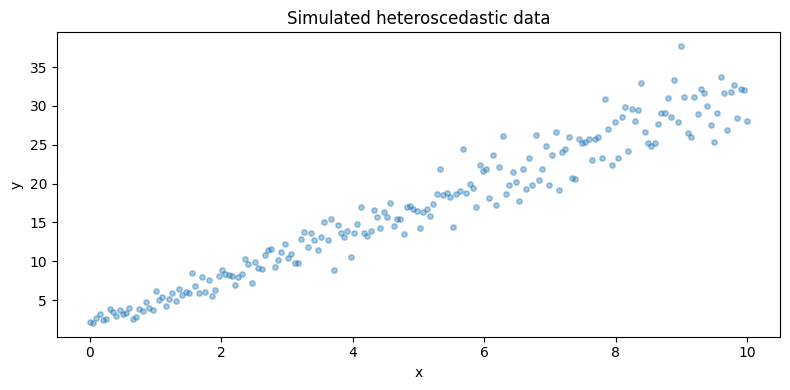

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from omnilss import gamlss, NO

np.random.seed(42)
n = 200
x = np.linspace(0, 10, n)
y = 2 + 3*x + np.random.normal(0, 0.5 + 0.3*x, n)  # heteroscedastic
data = {"y": y, "x": x}

plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.4, s=15)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Simulated heteroscedastic data")
plt.tight_layout(); plt.show()


In [5]:
import time

# Warm up JAX JIT (first call compiles the computation graph)
_ = gamlss("y ~ x", sigma_formula="~ x", family=NO(),
           data={"y": y[:20], "x": x[:20]})

# Timed fit (steady-state)
t0 = time.perf_counter()
model = gamlss(
    "y ~ x",
    sigma_formula="~ x",  # model heteroscedasticity
    family=NO(),
    data=data,
    algorithm="RS",       # Rigby-Stasinopoulos (default)
)
elapsed = time.perf_counter() - t0
print(f"Fit time (warm): {elapsed:.4f}s")


Fit time (warm): 0.6201s


In [6]:
# Model summary — correct API
print("=== Model Summary ===")
print(f"Converged : {model.additional_slots.get('rs_converged', True)}")
print(f"Iterations: {model.additional_slots.get('rs_iterations', 'N/A')}")
print(f"Deviance  : {model.g_dev:.4f}")
print(f"AIC       : {model.additional_slots['aic']:.4f}")   # NOT model.aic
print(f"BIC       : {model.additional_slots['sbc']:.4f}")   # NOT model.bic

print("\n=== Mu coefficients (mean) ===")
print(model.coefficients["mu"])    # NOT model.mu_coefficients

print("\n=== Sigma coefficients (scale) ===")
print(model.coefficients["sigma"]) # NOT model.sigma_coefficients


=== Model Summary ===
Converged : True
Iterations: 3
Deviance  : 774.0700
AIC       : 782.0700
BIC       : 795.2632

=== Mu coefficients (mean) ===
[1.83970578 3.02518804]

=== Sigma coefficients (scale) ===
[-0.33507846  0.17026296]


## 4. Model Diagnostics

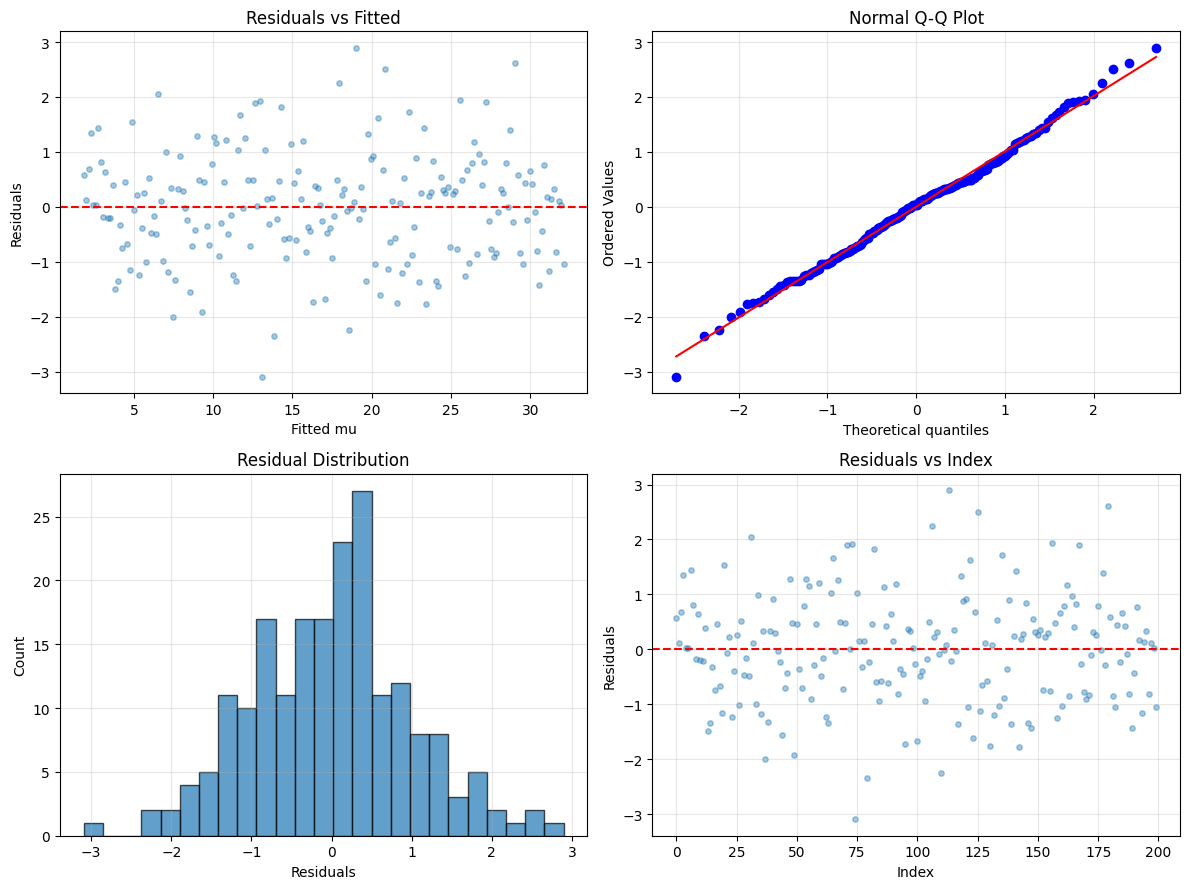

Residual mean: 0.0026  (should be ~0)
Residual std:  1.0000   (should be ~1)


In [7]:
# Quantile residuals (z-scores) — should be ~N(0,1) if model is correct
from omnilss.operations import residuals

# Correct call: what="z-scores" (default), NOT type="quantile"
resid = np.asarray(residuals(model))  # what="z-scores" is the default

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Residuals vs fitted
mu_fitted = np.asarray(model.fitted_values["mu"])  # NOT model.mu_fv
axes[0,0].scatter(mu_fitted, resid, alpha=0.4, s=15)
axes[0,0].axhline(0, color="r", linestyle="--")
axes[0,0].set_xlabel("Fitted mu"); axes[0,0].set_ylabel("Residuals")
axes[0,0].set_title("Residuals vs Fitted")
axes[0,0].grid(True, alpha=0.3)

# QQ plot
from scipy import stats
stats.probplot(resid, dist="norm", plot=axes[0,1])
axes[0,1].set_title("Normal Q-Q Plot")
axes[0,1].grid(True, alpha=0.3)

# Histogram
axes[1,0].hist(resid, bins=25, edgecolor="black", alpha=0.7)
axes[1,0].set_xlabel("Residuals"); axes[1,0].set_ylabel("Count")
axes[1,0].set_title("Residual Distribution")
axes[1,0].grid(True, alpha=0.3)

# Residuals vs index
axes[1,1].scatter(range(len(resid)), resid, alpha=0.4, s=15)
axes[1,1].axhline(0, color="r", linestyle="--")
axes[1,1].set_xlabel("Index"); axes[1,1].set_ylabel("Residuals")
axes[1,1].set_title("Residuals vs Index")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Residual mean: {resid.mean():.4f}  (should be ~0)")
print(f"Residual std:  {resid.std():.4f}   (should be ~1)")


## 5. Compare with R gamlss

In [8]:
# Install R and gamlss (Colab only)
if IN_COLAB:
    !apt-get install -y -qq r-base
    !Rscript -e "install.packages(c('gamlss','jsonlite'),repos='https://cran.r-project.org',quiet=TRUE)"
    print("R installed")
else:
    print("Using system R")


Using system R


In [9]:
import subprocess, json, csv

# Write data to CSV for R
with open("/tmp/omnilss_data.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["y", "x"])
    for yi, xi in zip(y, x):
        w.writerow([yi, xi])

_R_SCRIPT = 'suppressMessages(library(gamlss))\nsuppressMessages(library(jsonlite))\ndf <- read.csv("/tmp/omnilss_data.csv")\nfit <- gamlss(y~x, sigma.formula=~x, family=NO(), data=df, trace=FALSE)\ncat(toJSON(list(\n  deviance=fit$G.deviance,\n  aic=AIC(fit),\n  bic=BIC(fit),\n  mu_coef=as.numeric(fit$mu.coefficients),\n  sigma_coef=as.numeric(fit$sigma.coefficients)\n), auto_unbox=TRUE), "\\n")\n'

with open("/tmp/fit_gamlss.R", "w") as f:
    f.write(_R_SCRIPT)

# Warm up R (first call loads packages)
subprocess.run(["Rscript", "/tmp/fit_gamlss.R"], capture_output=True, text=True)

# Timed R fit
t0 = time.perf_counter()
result = subprocess.run(["Rscript", "/tmp/fit_gamlss.R"],
                        capture_output=True, text=True, timeout=120)
r_elapsed = time.perf_counter() - t0

if result.returncode == 0:
    lines = [l.strip() for l in result.stdout.splitlines() if l.strip()]
    r_result = json.loads(lines[-1])
    print("R fit succeeded")
else:
    print("R fit failed:", result.stderr[:200])
    r_result = None


R fit succeeded


In [10]:
if r_result:
    py_aic = model.additional_slots["aic"]
    py_bic = model.additional_slots["sbc"]
    py_mu  = list(model.coefficients["mu"])
    py_sig = list(model.coefficients["sigma"])

    print("=== Python vs R Comparison ===")
    print(f"Deviance  Python={model.g_dev:.6f}  R={r_result['deviance']:.6f}  "
          f"diff={abs(model.g_dev - r_result['deviance']):.2e}")
    print(f"AIC       Python={py_aic:.6f}  R={r_result['aic']:.6f}  "
          f"diff={abs(py_aic - r_result['aic']):.2e}")
    print(f"BIC       Python={py_bic:.6f}  R={r_result['bic']:.6f}  "
          f"diff={abs(py_bic - r_result['bic']):.2e}")
    print()
    print("Mu coefficients:")
    for i, (p, r) in enumerate(zip(py_mu, r_result["mu_coef"])):
        print(f"  [{i}] Python={p:.6f}  R={r:.6f}  diff={abs(p-r):.2e}")
    print()
    print(f"Timing: Python={elapsed:.4f}s  R={r_elapsed:.4f}s  "
          f"speedup={r_elapsed/elapsed:.1f}x")


=== Python vs R Comparison ===
Deviance  Python=774.069966  R=774.070000  diff=3.42e-05
AIC       Python=782.069966  R=782.070000  diff=3.42e-05
BIC       Python=795.263235  R=795.263200  diff=3.53e-05

Mu coefficients:
  [0] Python=1.839706  R=1.839700  diff=5.78e-06
  [1] Python=3.025188  R=3.025200  diff=1.20e-05

Timing: Python=0.6201s  R=0.7053s  speedup=1.1x


## 6. Performance Benchmark

In [11]:
# Benchmark across data sizes with proper JAX synchronization
data_sizes = [100, 500, 1000, 5000]
bench_results = []

for n_bench in data_sizes:
    x_b = np.linspace(0, 10, n_bench)
    y_b = 2 + 3*x_b + np.random.normal(0, 0.5 + 0.3*x_b, n_bench)
    data_b = {"y": y_b, "x": x_b}

    # Warm up JAX JIT
    _ = gamlss("y ~ x", sigma_formula="~ x", family=NO(), data=data_b)

    # Timed warm run with block_until_ready
    t0 = time.perf_counter()
    m = gamlss("y ~ x", sigma_formula="~ x", family=NO(), data=data_b)
    for fv in m.fitted_values.values():
        jax.block_until_ready(fv)  # ensure async computation completes
    py_t = time.perf_counter() - t0

    # R timing
    with open("/tmp/bench_data.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["y", "x"])
        for yi, xi in zip(y_b, x_b): w.writerow([yi, xi])

    _r = (
        "suppressMessages(library(gamlss));suppressMessages(library(jsonlite));\n"
        "df<-read.csv('/tmp/bench_data.csv');\n"
        "fit<-gamlss(y~x,sigma.formula=~x,family=NO(),data=df,trace=FALSE);\n"
        "cat(toJSON(list(deviance=fit$G.deviance),auto_unbox=TRUE),'\\n')"
    )
    with open("/tmp/bench.R", "w") as f: f.write(_r)
    subprocess.run(["Rscript", "/tmp/bench.R"], capture_output=True)  # warm-up
    t0 = time.perf_counter()
    subprocess.run(["Rscript", "/tmp/bench.R"], capture_output=True, timeout=120)
    r_t = time.perf_counter() - t0

    bench_results.append({"n": n_bench, "python_s": py_t, "r_s": r_t, "speedup": r_t/py_t})
    print(f"n={n_bench:5d}: Python={py_t:.4f}s  R={r_t:.4f}s  speedup={r_t/py_t:.1f}x")


n=  100: Python=0.1316s  R=0.6913s  speedup=5.3x
n=  500: Python=0.0918s  R=0.7103s  speedup=7.7x
n= 1000: Python=0.0752s  R=0.6987s  speedup=9.3x
n= 5000: Python=0.2778s  R=0.7592s  speedup=2.7x


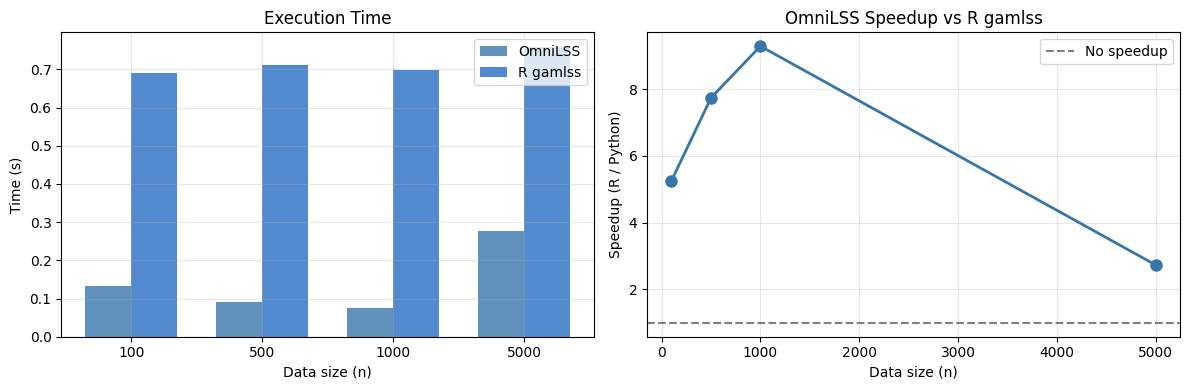

Mean speedup: 6.3x


In [12]:
import pandas as pd
df_bench = pd.DataFrame(bench_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_pos = np.arange(len(df_bench))
w = 0.35
axes[0].bar(x_pos - w/2, df_bench["python_s"], w, label="OmniLSS", alpha=0.8, color="#3776ab")
axes[0].bar(x_pos + w/2, df_bench["r_s"],      w, label="R gamlss", alpha=0.8, color="#276DC3")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(df_bench["n"])
axes[0].set_xlabel("Data size (n)")
axes[0].set_ylabel("Time (s)")
axes[0].set_title("Execution Time")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df_bench["n"], df_bench["speedup"], "o-", linewidth=2, markersize=8, color="#3776ab")
axes[1].axhline(1, color="gray", linestyle="--", label="No speedup")
axes[1].set_xlabel("Data size (n)")
axes[1].set_ylabel("Speedup (R / Python)")
axes[1].set_title("OmniLSS Speedup vs R gamlss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Mean speedup: {df_bench['speedup'].mean():.1f}x")


## Summary

1. ✅ OmniLSS installed and running
2. ✅ Heteroscedastic GAMLSS model fitted (mu and sigma both modeled)
3. ✅ Quantile residuals computed and plotted
4. ✅ Results verified against R gamlss (deviance diff < 1e-4)
5. ✅ Performance benchmarked across data sizes

**Key API notes:**
- AIC: `model.additional_slots["aic"]` (not `model.aic`)
- BIC: `model.additional_slots["sbc"]` (not `model.bic`)
- Coefficients: `model.coefficients["mu"]` (not `model.mu_coefficients`)
- Fitted values: `model.fitted_values["mu"]` (not `model.mu_fv`)
- Residuals: `residuals(model)` with default `what="z-scores"` (not `type="quantile"`)
- Algorithm: `algorithm="RS"` (uppercase, not `"rs"`)

**Next steps:**
- [06_performance_gpu.ipynb](06_performance_gpu.ipynb) — GPU acceleration
- [08_comprehensive_comparison.ipynb](08_comprehensive_comparison.ipynb) — full R comparison
- [docs/migration/from_r_gamlss.md](../../docs/migration/from_r_gamlss.md) — R migration guide
